In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    RocCurveDisplay, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance

# Multimodal classic ML

This is based on the classic.ipynb script from before, but adding even more features making the approach multimodal.

In [2]:
# Load the df
DATA_PATH = "/home/data/PPMI/documents/PPMI_Curated_Data_Cut_Public_20240729.xlsx"

LABEL_COL = "COHORT"
FEATURE_COLS = ['DATSCAN_CAUDATE_L', 'DATSCAN_CAUDATE_R', 'DATSCAN_PUTAMEN_L', 'DATSCAN_PUTAMEN_R']
 
LABEL_MAP = {1: 1, 2: 0}   # 1 = PD, 0 = HC
RANDOM_STATE = 42
CV_FOLDS = 5

# get data from excel into pd
import pandas as pd
df = pd.read_excel(DATA_PATH, header=0)

df[LABEL_COL] = df[LABEL_COL].map(LABEL_MAP)
df.dropna(subset=[LABEL_COL], inplace=True)
df[LABEL_COL] = df[LABEL_COL].astype(int)

df.dropna(subset=FEATURE_COLS, inplace=True)
 
print(f"Loaded {df.shape[0]} rows, {df.shape[1]} columns.")
print(f"After cleaning: {df.shape[0]} samples")
print(df[LABEL_COL].value_counts())

Loaded 3362 rows, 158 columns.
After cleaning: 3362 samples
COHORT
1    3066
0     296
Name: count, dtype: int64


Once the full df is loaded, im defining the different sets of features I'll be testing.

## Feature set definitions

In [3]:
# Feature set definitions
# All sets are additive: each builds on the previous one

# DaTscan raw (current baseline)
FEATS_DATSCAN_RAW = ['DATSCAN_CAUDATE_L', 'DATSCAN_CAUDATE_R', 'DATSCAN_PUTAMEN_L', 'DATSCAN_PUTAMEN_R']

# DaTscan raw + PPMI-derived SBR columns (lateralisation info)
FEATS_DATSCAN_FULL = FEATS_DATSCAN_RAW + [
    "con_caudate", "ips_caudate", "mean_caudate",
    "con_putamen", "ips_putamen", "mean_putamen",
    "con_striatum", "ips_striatum", "mean_striatum"
]


# Engineered features
eps = 1e-6 # avoid 0 div
df["AI_Caudate"]           = (df["DATSCAN_CAUDATE_L"] - df["DATSCAN_CAUDATE_R"]).abs() / ((df["DATSCAN_CAUDATE_L"] + df["DATSCAN_CAUDATE_R"]) / 2 + eps)
df["AI_Putamen"]           = (df["DATSCAN_PUTAMEN_L"] - df["DATSCAN_PUTAMEN_R"]).abs() / ((df["DATSCAN_PUTAMEN_L"] + df["DATSCAN_PUTAMEN_R"]) / 2 + eps)
df["Mean_SBR"]             = df[["DATSCAN_PUTAMEN_L", "DATSCAN_PUTAMEN_R", "DATSCAN_CAUDATE_L", "DATSCAN_CAUDATE_R"]].mean(axis=1)
df["Putamen_Caudate_Ratio"] = ((df["DATSCAN_PUTAMEN_L"] + df["DATSCAN_PUTAMEN_R"]) / 2) / ((df["DATSCAN_CAUDATE_L"] + df["DATSCAN_CAUDATE_R"]) / 2 + eps)


FEATURE_COLS_ENG = FEATURE_COLS + [ "AI_Caudate", "AI_Putamen", "Mean_SBR", "Putamen_Caudate_Ratio"]
# Engineered asymmetry features (already computed in df_model)
FEATS_DATSCAN_ENG = FEATS_DATSCAN_FULL + [
    "AI_Caudate", "AI_Putamen", "Mean_SBR", "Putamen_Caudate_Ratio"
]

# + Demographics (age and sex, known to affect DaTscan values)
FEATS_DEMO = FEATS_DATSCAN_ENG + ["age_at_visit", "SEX"]

# + Motor (UPDRS3 explicitly named in thesis, symptom flags less leaky)
FEATS_MOTOR = FEATS_DEMO + [
    "updrs3_score", "updrs1_score", "updrs2_score",
    "sym_tremor", "sym_rigid", "sym_brady", "sym_posins",
    "hy", "LEDD"
]

# + Non-motor prodromal markers (UPSIT explicitly named in thesis)
FEATS_NONMOTOR = FEATS_MOTOR + [
    "upsit", "rem", "ess", "gds",
    "scopa_gi", "scopa_ur"
]

# + Secondary biomarkers (sparse, expect more missing data here)
FEATS_BIO = FEATS_NONMOTOR + ["asyn", "nfl_serum", "urate"]

feature_sets = {
    "DaTscan raw":         FEATS_DATSCAN_RAW,
    "DaTscan full SBR":    FEATS_DATSCAN_FULL,
    "DaTscan engineered":  FEATS_DATSCAN_ENG,
    "+ Demographics":      FEATS_DEMO,
    "+ Motor (UPDRS)":     FEATS_MOTOR,
    "+ Non-motor (UPSIT)": FEATS_NONMOTOR,
    "+ Biomarkers":        FEATS_BIO,
}

The last dictionary defines a dictionary correspoding to a list of features.

Now for each of these the datasets need to be built.

# Building the datasets

In [4]:
from sklearn.impute import SimpleImputer

def prepare_dataset(df, feature_cols, label_col="COHORT", random_state=42):
    """
    For a given feature set:
    - drops rows where ALL features are missing
    - imputes remaining NaNs with column median
    - undersamples majority class to match minority
    Returns X (np.array), y (np.array), and feature names after imputation
    """
    subset = df[feature_cols + [label_col]].copy()
    subset.dropna(how="all", subset=feature_cols, inplace=True)

    X_raw = subset[feature_cols].values
    y_raw = subset[label_col].values

    # Median imputation (robust to outliers, safe for clinical data)
    imputer = SimpleImputer(strategy="median")
    X_imp = imputer.fit_transform(X_raw)

    # Undersample majority class
    n_hc = (y_raw == 0).sum()
    n_pd = (y_raw == 1).sum()
    minority_n = min(n_hc, n_pd)

    rng = np.random.RandomState(random_state)
    hc_idx = np.where(y_raw == 0)[0]
    pd_idx = np.where(y_raw == 1)[0]
    hc_sampled = rng.choice(hc_idx, size=minority_n, replace=False)
    pd_sampled = rng.choice(pd_idx, size=minority_n, replace=False)
    idx = np.concatenate([hc_sampled, pd_sampled])

    print(f"  {len(feature_cols):3d} features | {len(idx):4d} samples "
          f"(PD: {minority_n}, HC: {minority_n}) | "
          f"NaN rate before imputation: {np.isnan(X_raw).mean():.1%}")

    return X_imp[idx], y_raw[idx]

print("Preparing datasets...")
prepared = {}
for name, feats in feature_sets.items():
    print(f"\n{name}")
    # Only use columns that actually exist in df_model
    available = [f for f in feats if f in df.columns]
    missing_cols = set(feats) - set(available)
    if missing_cols:
        print(f"Columns not found, skipping: {missing_cols}")
    X_d, y_d = prepare_dataset(df, available)
    prepared[name] = (X_d, y_d, available)

Preparing datasets...

DaTscan raw
    4 features |  592 samples (PD: 296, HC: 296) | NaN rate before imputation: 0.0%

DaTscan full SBR
   13 features |  592 samples (PD: 296, HC: 296) | NaN rate before imputation: 0.2%

DaTscan engineered
   17 features |  592 samples (PD: 296, HC: 296) | NaN rate before imputation: 0.2%

+ Demographics
   19 features |  592 samples (PD: 296, HC: 296) | NaN rate before imputation: 0.2%

+ Motor (UPDRS)
   28 features |  592 samples (PD: 296, HC: 296) | NaN rate before imputation: 2.6%

+ Non-motor (UPSIT)
   34 features |  592 samples (PD: 296, HC: 296) | NaN rate before imputation: 3.8%

+ Biomarkers
   37 features |  592 samples (PD: 296, HC: 296) | NaN rate before imputation: 7.2%


Now, i'll just use the same classifiers as last time and run CV across all features sets at once:

# Classifiers and CV

In [5]:
classifiers = {
    "SVM (RBF)":           SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, class_weight="balanced", random_state=RANDOM_STATE),
    "SVM (Linear)":        SVC(kernel="linear", C=1.0, probability=True, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest":       RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=RANDOM_STATE),
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
}

In [6]:
from sklearn.metrics import make_scorer, precision_score, recall_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "accuracy":          "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "roc_auc":           "roc_auc",
    "f1":                "f1",
    "precision_macro":   make_scorer(precision_score, average="macro"),
    "recall_macro":      make_scorer(recall_score, average="macro"),
}

In [7]:
multimodal_results = {}

print("Multimodal CV, best classifier (SVM RBF) across feature sets")

# Run all classifiers but print only SVM RBF for brevity;
# store all for the plot
for fs_name, (X_d, y_d, feats) in prepared.items():
    multimodal_results[fs_name] = {}
    for clf_name, clf in classifiers.items():
        pipe = Pipeline([("scaler", StandardScaler()), ("clf", clf)])
        scores = cross_validate(pipe, X_d, y_d, cv=cv, scoring=scoring, n_jobs=-1)
        multimodal_results[fs_name][clf_name] = scores

    # Print summary for SVM RBF only
    s = multimodal_results[fs_name]["SVM (RBF)"]
    print(f"\n{fs_name}")
    print(f"  AUC      : {s['test_roc_auc'].mean():.3f} ± {s['test_roc_auc'].std():.3f}")
    print(f"  Bal. Acc : {s['test_balanced_accuracy'].mean():.3f} ± {s['test_balanced_accuracy'].std():.3f}")
    print(f"  F1       : {s['test_f1'].mean():.3f} ± {s['test_f1'].std():.3f}")
    print(f"  Precision: {s['test_precision_macro'].mean():.3f} ± {s['test_precision_macro'].std():.3f}")
    print(f"  Recall   : {s['test_recall_macro'].mean():.3f} ± {s['test_recall_macro'].std():.3f}")

Multimodal CV, best classifier (SVM RBF) across feature sets

DaTscan raw
  AUC      : 0.992 ± 0.012
  Bal. Acc : 0.975 ± 0.015
  F1       : 0.975 ± 0.015
  Precision: 0.975 ± 0.015
  Recall   : 0.975 ± 0.015

DaTscan full SBR
  AUC      : 0.994 ± 0.008
  Bal. Acc : 0.976 ± 0.015
  F1       : 0.976 ± 0.015
  Precision: 0.977 ± 0.015
  Recall   : 0.976 ± 0.015

DaTscan engineered
  AUC      : 0.995 ± 0.007
  Bal. Acc : 0.978 ± 0.014
  F1       : 0.978 ± 0.014
  Precision: 0.978 ± 0.014
  Recall   : 0.978 ± 0.014

+ Demographics
  AUC      : 0.995 ± 0.006
  Bal. Acc : 0.978 ± 0.016
  F1       : 0.978 ± 0.016
  Precision: 0.978 ± 0.016
  Recall   : 0.978 ± 0.016

+ Motor (UPDRS)
  AUC      : 1.000 ± 0.001
  Bal. Acc : 0.993 ± 0.008
  F1       : 0.993 ± 0.008
  Precision: 0.993 ± 0.008
  Recall   : 0.993 ± 0.008

+ Non-motor (UPSIT)
  AUC      : 0.999 ± 0.001
  Bal. Acc : 0.993 ± 0.008
  F1       : 0.993 ± 0.008
  Precision: 0.993 ± 0.008
  Recall   : 0.993 ± 0.008

+ Biomarkers
  AUC     

# Viewing results of the cummulative info gain

Plot the info gain per modality

In [8]:
import matplotlib.font_manager as fm
import matplotlib

fm._load_fontmanager(try_read_cache=False)  # force rescan
fm.fontManager.addfont("/home/akarel/.local/share/fonts/LinLibertine_R.ttf")  # explicit add
[f.name for f in fm.fontManager.ttflist if "Libertine" in f.name or "Libertinus" in f.name]
matplotlib.rcParams["font.family"] = "Linux Libertine"
matplotlib.rcParams["font.size"] = 14

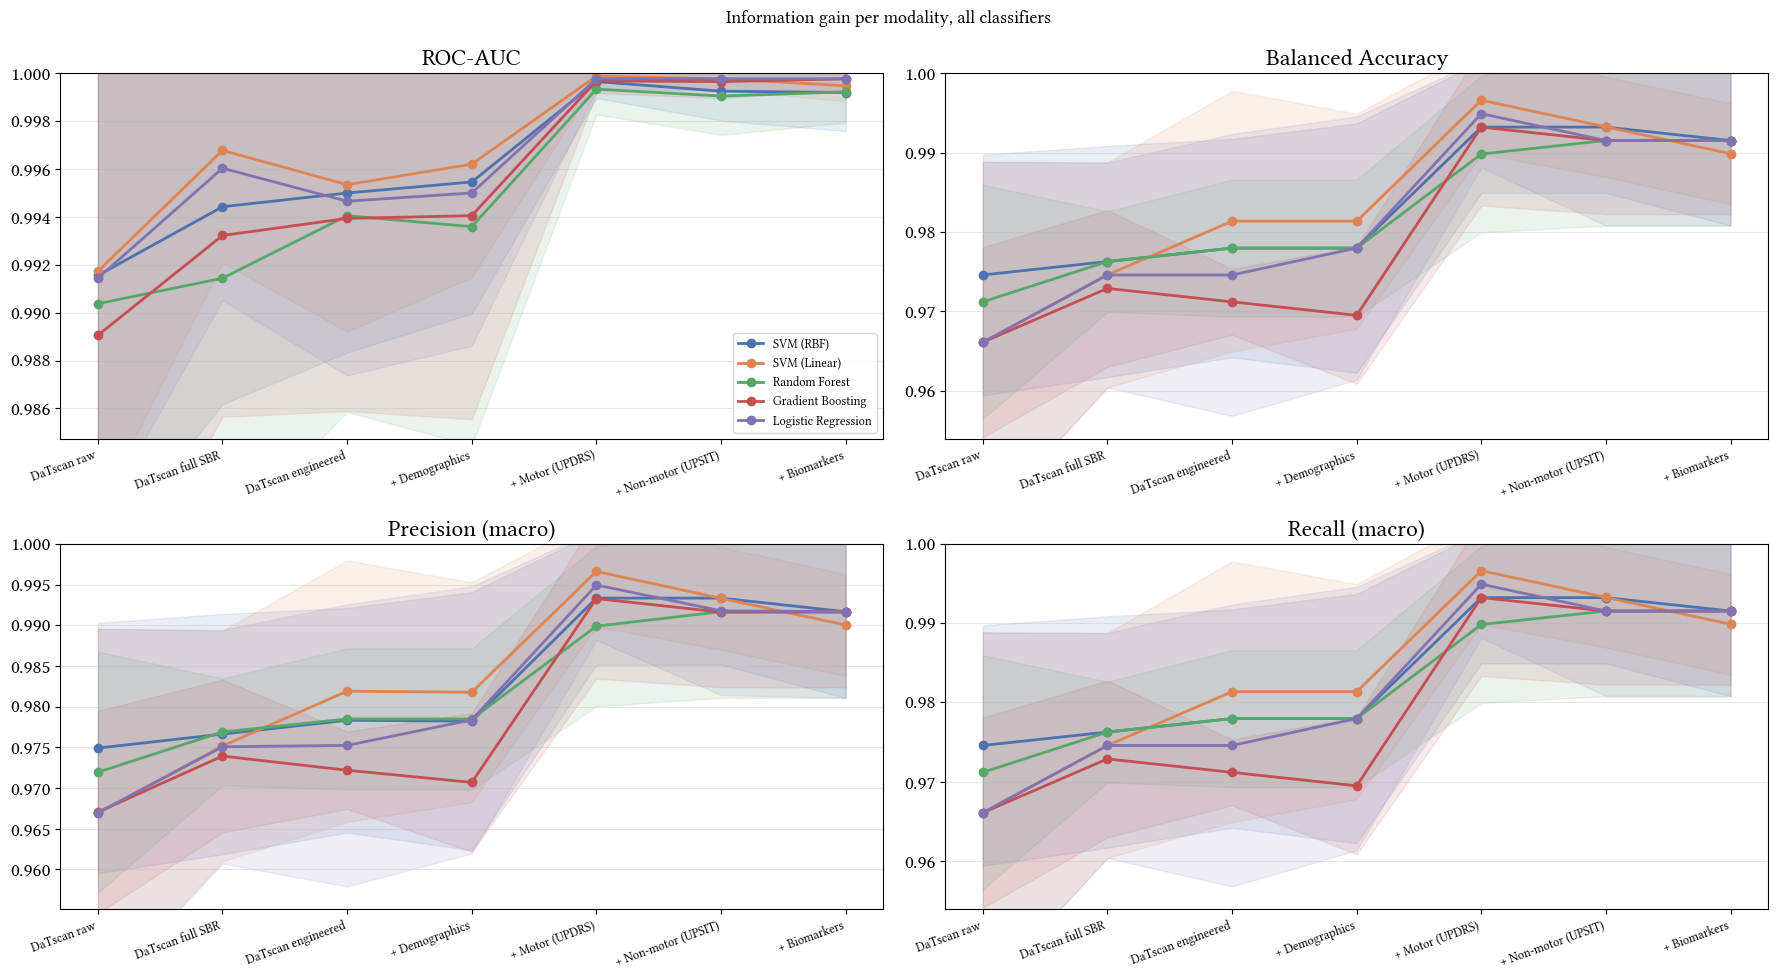

In [9]:
# One line per classifier, x-axis = feature set (modality added progressively)
# Focus metric: ROC-AUC and Balanced Accuracy side by side

plot_metrics = {
    "ROC-AUC":           "test_roc_auc",
    "Balanced Accuracy": "test_balanced_accuracy",
    "Precision (macro)": "test_precision_macro",
    "Recall (macro)":    "test_recall_macro",
}

clf_colors = {
    "SVM (RBF)":           "#4C72B0",
    "SVM (Linear)":        "#DD8452",
    "Random Forest":       "#55A868",
    "Gradient Boosting":   "#C44E52",
    "Logistic Regression": "#8172B2",
}

fs_names  = list(multimodal_results.keys())
x         = np.arange(len(fs_names))

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()

for ax, (metric_label, key) in zip(axes, plot_metrics.items()):
    for clf_name, color in clf_colors.items():
        means = [multimodal_results[fs][clf_name][key].mean() for fs in fs_names]
        stds  = [multimodal_results[fs][clf_name][key].std()  for fs in fs_names]
        ax.plot(x, means, marker="o", label=clf_name, color=color, lw=2)
        ax.fill_between(x,
                        np.array(means) - np.array(stds),
                        np.array(means) + np.array(stds),
                        alpha=0.12, color=color)

    ax.set_xticks(x)
    ax.set_xticklabels(fs_names, rotation=20, ha="right", fontsize=9)
    ax.set_title(metric_label)
    ax.grid(axis="y", alpha=0.3)
    all_vals = [multimodal_results[fs][clf][key].mean()
                for fs in fs_names for clf in classifiers]
    margin = (max(all_vals) - min(all_vals)) * 0.4
    ax.set_ylim(min(all_vals) - margin, 1.0)

axes[0].legend(fontsize=9, loc="lower right")
fig.suptitle("Information gain per modality, all classifiers", fontsize=13)
plt.tight_layout()
plt.savefig("multimodal_information_gain.svg", format="svg", bbox_inches="tight")
plt.show()

Commentary on the `org` file for 06 may.

In [10]:
import shap

fs_name = 'DaTscan engineered'
X_eng_bal, y_eng_bal, feats = prepared[fs_name]

# Fit on full balanced DaTscan-engineered dataset
pipe_shap = Pipeline([("scaler", StandardScaler()), ("clf", classifiers["SVM (RBF)"])])
pipe_shap.fit(X_eng_bal, y_eng_bal)

# SHAP expects the raw features; use the scaler transform
X_scaled = pipe_shap.named_steps["scaler"].transform(X_eng_bal)
# explainer = shap.KernelExplainer(
#     pipe_shap.named_steps["clf"].predict_proba,
#     shap.sample(X_scaled, 100)   # background sample, keep small for SVM
# )
# shap_values = explainer.shap_values(X_scaled[:200])  # explain first 200 samples

# shap.summary_plot(
#     shap_values[1],   # class 1 = PD
#     X_scaled[:200],
#     feature_names=FEATS_DATSCAN_ENG,
#     show=False
# )
# plt.title("SHAP feature importance: SVM RBF, DaTscan engineered features")
# plt.tight_layout()
# plt.savefig("shap_summary.svg", format="svg", bbox_inches="tight")
# plt.show()

/home/akarel/src_tfg/pt_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  0%|          | 0/200 [00:00<?, ?it/s]

100%|██████████| 200/200 [03:26<00:00,  1.03s/it]


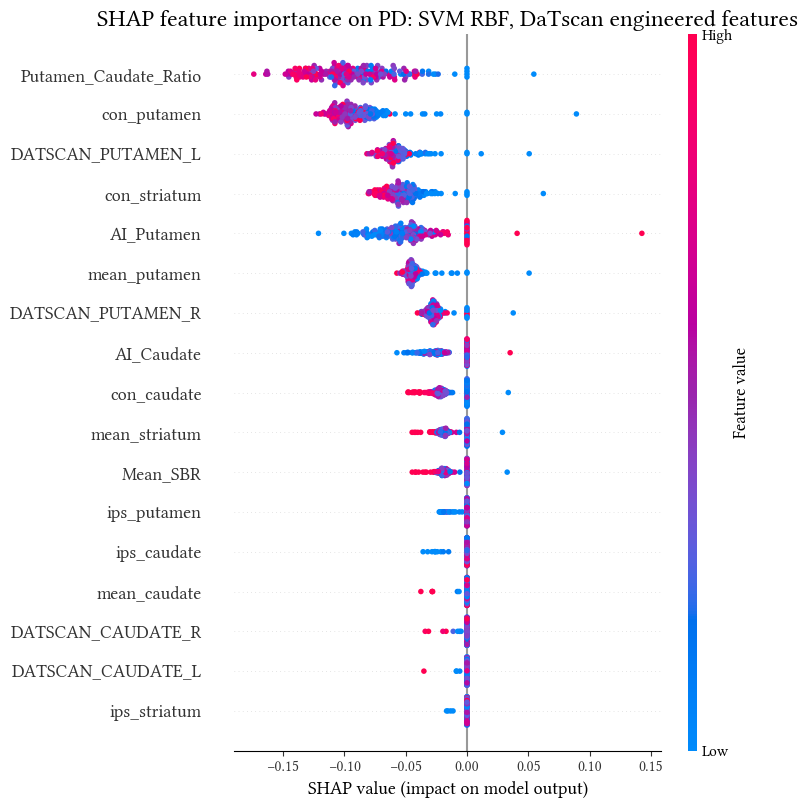

In [13]:
# Use prepared dataset directly so shapes are guaranteed to match
X_shap, y_shap, feats_shap = prepared["DaTscan engineered"]

pipe_shap = Pipeline([("scaler", StandardScaler()), ("clf", classifiers["SVM (RBF)"])])
pipe_shap.fit(X_shap, y_shap)

X_scaled = pipe_shap.named_steps["scaler"].transform(X_shap)

explainer = shap.KernelExplainer(
    pipe_shap.named_steps["clf"].predict_proba,
    shap.sample(X_scaled, 100)
)
shap_values = explainer.shap_values(X_scaled[:200])

# feats_shap is the actual list of features that survived
shap.summary_plot(
    shap_values[:, :, 1], # all classes, all features, PD only
    X_scaled[:200],
    feature_names=feats_shap,
    show=False,
    max_display=100
)
plt.title("SHAP feature importance on PD: SVM RBF, DaTscan engineered features")
plt.tight_layout()
plt.savefig("shap_summary_PD.svg", format="svg", bbox_inches="tight")
plt.show()